# Week 10 — Computer Vision with Convolutional Neural Networks

## Day 1 — Session 1: From Fully Connected Networks to CNNs

**Main Theme:** Why do we need Convolutional Neural Networks?

### Learning Objectives

By the end of this session, students should be able to:

1. Explain why a fully connected network is inefficient for image data.
2. Represent an image as a tensor.
3. Explain the ideas of **local connectivity** and **parameter sharing**.
4. Describe a convolutional filter/kernel and feature map.
5. Perform a small convolution operation manually.
6. Explain the role of:

   * Kernel size
   * Stride
   * Padding
7. Calculate the spatial output size of a convolution layer.
8. Explain intuitively why CNNs are effective for visual data.

---

# 1. Connection to Week 9 — How Do We Train Deep Networks?


Before introducing CNNs, connect today's topic to everything students learned in Weeks 8 and 9.

We already know how a neural network works:

```text
Input
  ↓
Linear Transformation
  ↓
Activation
  ↓
Linear Transformation
  ↓
Activation
  ↓
Output
  ↓
Loss
  ↓
Backpropagation
  ↓
Gradient Descent
```

We also learned how to make deep networks train better:

* Activation functions
* Weight initialization
* Gradient-based optimization
* Learning rate
* Learning-rate scheduling
* Weight decay
* Dropout
* Regularization
* Overfitting prevention

Today we are **not replacing these ideas**.

Instead, we are changing the architecture of the network so that it is better suited to a particular type of data:

> **Images.**

---

## Opening Question

Ask students:

> Suppose we want to classify images of cats and dogs. Why can't we simply use the fully connected neural network we already know?

Let students think for a few seconds.

Then show the following example.

---

# 2. Why Is a Fully Connected Network Bad for Images?


Consider a color image:

$$
224 \times 224 \times 3
$$

where:

* $224$ = height
* $224$ = width
* $3$ = RGB channels

The total number of input values is:

$$
224 \times 224 \times 3 = 150,528
$$

So the image becomes a vector with:

$$
150,528
$$

input features.

Suppose the first fully connected layer contains 1,000 neurons.

Each neuron needs one weight for every input:

$$
150,528 \times 1,000
$$

Therefore:

$$
150,528,000
$$

weights are required.

Including 1,000 biases:

$$
150,529,000
$$

parameters.

That's approximately:

$$
150.5\text{ million parameters}
$$

**from just one layer.**

---

## Interactive Question

Ask:

> Is having 150 million parameters necessarily bad?

The answer is:

**Not necessarily.**

The real problem is that a fully connected layer does not understand the structure of an image.

There are three major problems.

---

# 3. Problem 1 — Too Many Parameters

A fully connected layer connects every input pixel to every neuron.

```text
Pixel 1 ─────────┐
Pixel 2 ─────────┤
Pixel 3 ─────────┤
Pixel 4 ─────────┤──→ Neuron
Pixel 5 ─────────┤
      ...        │
Pixel 150528 ────┘
```

Every connection has its own weight.

This creates:

* Huge memory requirements
* More computation
* Higher risk of overfitting
* More difficult optimization

But there is an even deeper problem.

---

# 4. Problem 2 — Images Have Spatial Structure

Consider this simple image:



Pixels close to each other are usually related.

For example, neighboring pixels can form:

* Edges
* Corners
* Textures
* Shapes
* Object parts

A fully connected network treats the input as essentially:

```text
[Pixel1, Pixel2, Pixel3, ..., Pixel150528]
```

It does not explicitly know that:

```text
Pixel 100
```

is next to:

```text
Pixel 101
```

and:

```text
Pixel 100
```

is spatially related to another nearby pixel.

CNNs are designed specifically to exploit this spatial structure.

---

# 5. Problem 3 — The Same Pattern Can Appear Anywhere

Imagine an image containing a vertical edge.

It could appear:

```text
┌─────────────┐
│       │     │
│       │     │
│       │     │
│       │     │
└─────────────┘
```

or:

```text
┌─────────────┐
│   │         │
│   │         │
│   │         │
│   │         │
└─────────────┘
```

The pattern is essentially the same.

We don't want to learn a completely different detector for every possible location.

We want to learn:

> "What does a vertical edge look like?"

and then search for that pattern throughout the image.

This leads to one of the most important ideas in CNNs:

# Parameter Sharing

The **same filter** can be applied at different locations.

---

# 6. The CNN Idea

A CNN replaces the idea:

> "Connect everything to everything."

with:

> "Look at small local regions and detect useful patterns."

Instead of processing the entire image at once, we use a small matrix called a:

* **Kernel**
* **Filter**

For example:

$$
3 \times 3
$$

The filter moves across the image.

```text
Image

┌─────────────────┐
│                 │
│   ┌─────┐       │
│   │ 3×3 │       │
│   │Kernel       │
│   └─────┘       │
│                 │
└─────────────────┘
```

At every position, the filter performs a small mathematical operation.

The result is a new matrix called a:

> **Feature Map**

---

# 7. Image as a Tensor


Before performing convolution, we need to understand how an image is represented.

## Grayscale Image

A grayscale image contains one channel.

For example:

$$
28 \times 28
$$

Each value represents pixel intensity.

```text
0     → black
255   → white
```

Example:

$$
\begin{bmatrix}
0 & 0 & 10 & 20 \\
0 & 30 & 80 & 100 \\
10 & 60 & 150 & 200\\
20 & 100 & 200 & 255
\end{bmatrix}
$$

---

# 8. RGB Image

A color image usually has three channels:

```text
Red
Green
Blue
```

So an image can be represented as:

$$
H \times W \times C
$$

For example:

$$
224 \times 224 \times 3
$$

Conceptually:

```text
Image
 ├── Red Channel
 ├── Green Channel
 └── Blue Channel
```

---

# 9. How PyTorch Represents Images

PyTorch uses the format:

$$
[B,C,H,W]
$$

where:

* $B$ = Batch size
* $C$ = Channels
* $H$ = Height
* $W$ = Width

For example:

```text
[32, 3, 224, 224]
```

means:

```text
32 images
3 channels
224 pixels high
224 pixels wide
```

---

## Important Distinction

Students often confuse these two representations:

```text
Image conceptually:
H × W × C
```

versus:

```text
PyTorch:
C × H × W
```

and with batches:

```text
B × C × H × W
```

### Quick Question

What does this tensor represent?

```text
[64, 3, 32, 32]
```

Answer:

> A batch of 64 RGB images, each with resolution 32×32.

---

# From Matrices to Tensors

Modern Deep Learning frameworks represent images as tensors.
- Depending on the framework.
- Some representations allow efficient computation on GPUs.


| Tensor Type / Image Format | Tensor Shape | Description / Dimension Roles |
| :--- | :--- | :--- |
| **Grayscale Image** | `(H, W)` | **H**: Height, **W**: Width. Single 2D matrix representing spatial dimensions. |
| **RGB Image** | `(H, W, 3)` | **H**: Height, **W**: Width, **3**: Color Channels (Red, Green, Blue). |
| **Batch of Images (Channels Last)** | `(B, H, W, C)` | **B**: Batch size, **H**: Height, **W**: Width, **C**: Channels. Standard format in TensorFlow / Keras. |
| **Batch of Images (Channels First)** | `(B, C, H, W)` | **B**: Batch size, **C**: Channels, **H**: Height, **W**: Width. Standard format in PyTorch. |

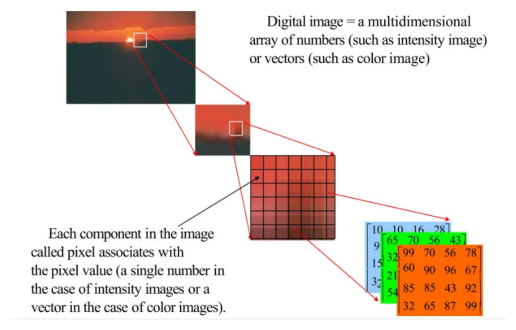

In [3]:
import cv2
import matplotlib.pyplot as plt

#plt.close('all')
img = cv2.imread("res/1_aNX556WCJXUi-ZhLwI8TUA.webp")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 10. What Is a Filter?


Before introducing learnable filters in CNNs, let's look at an important idea from **classical image processing**.

The basic idea is actually much older than deep learning:

> We can use a small matrix to detect a particular visual pattern in an image.

That small matrix is often called a:

* **Kernel**
* **Filter**

---

## 10.1 A Simple Edge Detector

Consider this kernel:

$$
K=
\begin{bmatrix}
-1&0&1\\
-1&0&1\\
-1&0&1
\end{bmatrix}
$$

When we slide this kernel across an image, it responds strongly to certain **vertical intensity changes**.

Conceptually:

```text
Dark  →  Bright
██████│░░░░░░
██████│░░░░░░
██████│░░░░░░
```

The kernel is essentially asking:

> "Is there a strong left-to-right change in intensity here?"

---

# 10.2 Classical Filters

Before CNNs became popular, computer vision engineers manually designed filters for different purposes.

Some famous examples include:

### Edge Detection

* Sobel
* Prewitt
* Roberts

### Smoothing

* Gaussian Blur
* Box Blur

### Sharpening

* Laplacian-based filters
* High-pass filters

The important idea is:

> **Different kernels produce different visual effects.**

---

# 10.3 Sobel Filter

One of the most famous examples is the **Sobel operator**.

The horizontal and vertical Sobel kernels are commonly written as:

### Detecting Vertical Edges

$$
G_x=
\begin{bmatrix}
-1&0&1\\
-2&0&2\\
-1&0&1
\end{bmatrix}
$$

### Detecting Horizontal Edges

$$
G_y=
\begin{bmatrix}
-1&-2&-1\\
0&0&0\\
1&2&1
\end{bmatrix}
$$

The first kernel responds strongly to changes in the horizontal direction, producing a **vertical-edge response**.

The second responds to changes in the vertical direction, producing a **horizontal-edge response**.

---

# 10.4 Why Does Sobel Work?

Suppose we have an image region like this:

```text
Dark       Bright
1 1 1      9 9 9
1 1 1      9 9 9
1 1 1      9 9 9
```

A kernel such as:

$$
\begin{bmatrix}
-1&0&1\\
-2&0&2\\
-1&0&1
\end{bmatrix}
$$

produces a large response because:

* The left side is dark.
* The right side is bright.
* There is a strong intensity transition.

Therefore:

> Large response → likely edge.

This is a very intuitive way to introduce the idea of a **feature detector**.

---

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

#plt.close('all')

# 1. Generate or load a highly textured sample image
# We'll create a clean synthetic image with geometric patterns and text to clearly showcase filters
img = np.zeros((300, 300), dtype=np.uint8)
cv2.rectangle(img, (30, 30), (140, 140), 255, -1)
cv2.circle(img, (220, 85), 55, 180, -1)
cv2.putText(img, "CNN", (65, 230), cv2.FONT_HERSHEY_SIMPLEX, 3, 255, 5, cv2.LINE_AA)
# Add some subtle noise to test smoothing filters
np.random.seed(42)
noise = np.random.normal(0, 15, img.shape).astype(np.float32)
img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

# 2. Define the exact kernel dictionary mapping
KERNELS = {
    "Original": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32),
    
    "Box Blur (Low-Pass)": np.ones((3, 3), dtype=np.float32) / 9.0,
    
    "Gaussian Blur": np.array([[1, 2, 1],
                               [2, 4, 2],
                               [1, 2, 1]], dtype=np.float32) / 16.0,
    
    "Sharpen (High-Pass)": np.array([[ 0, -1,  0],
                                     [-1,  5, -1],
                                     [ 0, -1,  0]], dtype=np.float32),
    
    "Sobel (Edge Detection X)": np.array([[-1, 0, 1],
                                          [-2, 0, 2],
                                          [-1, 0, 1]], dtype=np.float32),
    
    "Emboss (Directional)": np.array([[-2, -1, 0],
                                      [-1,  1, 1],
                                      [ 0,  1, 2]], dtype=np.float32)
}

def apply_spatial_filter(filter_name):
    """
    Retrieves the kernel matrix, performs spatial convolution, and displays
    the original vs filtered result side-by-side with kernel weights.
    """
    kernel = KERNELS[filter_name]
    
    # Perform strict 2D convolution
    # cv2.filter2D handles edge padding automatically via border reflection
    filtered_img = cv2.filter2D(img, ddepth=cv2.CV_32F, kernel=kernel)
    
    # Clean up edge maps / directional values for clean plotting
    if "Sobel" in filter_name or "Emboss" in filter_name:
        # Map negative gradients safely into absolute visible intensities
        filtered_img = np.abs(filtered_img)
    filtered_img = np.clip(filtered_img, 0, 255).astype(np.uint8)

    # ---- GRID VISUALIZATION ENGINE ----
    fig = plt.figure(figsize=(15, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.4, 1])
    
    ax_orig = fig.add_subplot(gs[0])
    ax_kern = fig.add_subplot(gs[1])
    ax_filt = fig.add_subplot(gs[2])
    
    # 1. Render Original Image Canvas
    ax_orig.imshow(img, cmap='gray')
    ax_orig.set_title("Input Image (with noise)", fontsize=12, fontweight='bold')
    ax_orig.axis('off')
    
    # 2. Display Kernel Structural Matrix
    ax_kern.imshow(kernel, cmap='coolwarm', interpolation='nearest', alpha=0.3)
    ax_kern.set_title(f"Kernel Weights\n({filter_name})", fontsize=11, fontweight='bold')
    ax_kern.set_xticks(range(3))
    ax_kern.set_yticks(range(3))
    # Overlay numerical labels on each element of the kernel matrix
    for i in range(3):
        for j in range(3):
            val = kernel[i, j]
            # Format display strings for clean fractional rendering
            label_str = f"{val:.2f}" if 0 < abs(val) < 1 else f"{int(val)}"
            ax_kern.text(j, i, label_str, ha='center', va='center', 
                         color='black', fontsize=12, fontweight='bold')
            
    # 3. Render Post-Convolution Canvas
    ax_filt.imshow(filtered_img, cmap='gray')
    ax_filt.set_title(f"Output Feature Map", fontsize=12, fontweight='bold')
    ax_filt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 3. Mount Interactive Dropdown Controller
interact(
    apply_spatial_filter,
    filter_name=widgets.Dropdown(
        options=list(KERNELS.keys()),
        value="Original",
        description="Select Filter:",
        disabled=False,
    )
);

interactive(children=(Dropdown(description='Select Filter:', options=('Original', 'Box Blur (Low-Pass)', 'Gaus…

# 10.5 Other Classical Filters

We can show students a few examples.

### Blur

A simple averaging filter:

$$
\frac{1}{9}
\begin{bmatrix}
1&1&1\\
1&1&1\\
1&1&1
\end{bmatrix}
$$

It smooths the image.

---

### Sharpening

For example:

$$
\begin{bmatrix}
0&-1&0\\
-1&5&-1\\
0&-1&0
\end{bmatrix}
$$

It emphasizes local intensity differences and makes edges appear sharper.

---

### Edge Detection

Sobel:

$$
\begin{bmatrix}
-1&0&1\\
-2&0&2\\
-1&0&1
\end{bmatrix}
$$

---

# 10.6 The Key Question

Now ask the students:

> What do all these filters have in common?

They are all:

1. Small matrices
2. Applied locally
3. Moved across the image
4. Using multiplication and summation
5. Producing a new representation of the image

In other words:

```text
Image
  ↓
Kernel
  ↓
Sliding Operation
  ↓
Feature Map
```

This is exactly the basic operation used by a CNN.

---

# 10.7 So What Is Different About CNNs?

This is the crucial transition.

In classical computer vision:

```text
Human
  ↓
Design Kernel
  ↓
Apply Kernel
  ↓
Feature Map
```

For example:

```text
Human-designed Sobel Kernel
              ↓
        Edge Detection
```

In a CNN:

```text
Training Data
      ↓
Neural Network
      ↓
Learn Kernel Weights
      ↓
Feature Maps
      ↓
Prediction
```

The CNN does **not** need us to explicitly tell it:

> "This kernel should detect vertical edges."

Instead, the weights are learned through:

$$
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Gradient Descent}
$$

---

# 10.8 Classical Filter vs CNN Filter

This comparison is worth putting directly on the slide:

| Classical Computer Vision             | CNN                                    |
| ------------------------------------- | -------------------------------------- |
| Human designs the kernel              | Network learns the kernel              |
| Fixed weights                         | Learnable weights                      |
| Designed for a specific purpose       | Learned from data                      |
| Example: Sobel                        | Example: Conv2d filter                 |
| Edge detection is explicitly designed | Useful features emerge during training |

The conceptual transition is:

$$
\boxed{
\text{Hand-designed Features}
\rightarrow
\text{Learned Features}
}
$$

This is one of the fundamental ideas behind the success of deep learning in computer vision.

---

# 10.9 CNN Filters Start Random

There is another important connection to Week 9.

At initialization, a CNN filter does **not** look like a nice Sobel filter.

For example, initially it may look like:

$$
\begin{bmatrix}
0.12&-0.03&0.07\\
-0.08&0.04&-0.11\\
0.02&0.09&-0.05
\end{bmatrix}
$$

These values are typically initialized automatically.

During training:

$$
W_{new} = W_{old}
- 
\eta
\frac{\partial L}{\partial W}
$$

The filter gradually changes to become useful for the task.

---

# 10.10 The Beautiful Connection to Week 9


> **Yesterday we learned that neural networks learn weights. Today we discover that the weights of a CNN are actually the filters that detect visual patterns.**

So:

```text
Week 9

Weights
   ↓
Learned by Backpropagation


Week 10

Convolutional Weights
   ↓
Learned Visual Filters
```

This gives a very concrete meaning to something that was previously abstract.

---

# 10.11 From Edges to Objects

A particularly important insight:

A first CNN layer may learn filters somewhat analogous to:

```text
Vertical edge
Horizontal edge
Diagonal edge
Color transition
Texture
```

Then deeper layers combine these simple patterns.

For example:

```text
Layer 1
Edges
  ↓
Layer 2
Corners + Textures
  ↓
Layer 3
Shapes
  ↓
Layer 4
Object Parts
  ↓
Classifier
Objects
```

So the CNN is effectively learning a hierarchy of visual representations.

---

# 10.12 Important Clarification


> "CNN filters are just Sobel filters."

That would be misleading.

Instead:

> **Sobel is a useful analogy for understanding what a convolutional filter can do, but CNN filters are learned from data and are not restricted to classical edge-detection patterns.**

A CNN may learn filters that detect:

* edges
* textures
* color combinations
* repeated patterns
* shapes
* task-specific structures

and deeper layers learn increasingly complex representations.

---

# 10.13 A Great Visual Demonstration

If you have time, this would be an excellent live demonstration:

```text
Original Image
      │
      ├──── Sobel X ────→ Vertical Edge Map
      │
      ├──── Sobel Y ────→ Horizontal Edge Map
      │
      └──── Blur ────────→ Smoothed Image
```

Then transition to:

```text
                    CNN
                     │
                     ▼
              Learned Filters
                     │
          ┌──────────┼──────────┐
          ▼          ▼          ▼
       Filter 1   Filter 2   Filter 3
          │          │          │
          ▼          ▼          ▼
      Feature Map Feature Map Feature Map
```


> **What if we don't know which filters are useful?**

Answer:

> **Let the neural network learn them.**

That is the conceptual bridge from **classical computer vision → CNNs**.

---

# 11. Manual Convolution Example

Let's make the example small enough to calculate by hand.

Consider a $5\times5$ image:

$$
X=
\begin{bmatrix}
1&2&3&4&5\\
2&3&4&5&6\\
3&4&5&6&7\\
4&5&6&7&8\\
5&6&7&8&9
\end{bmatrix}
$$

And a $3\times3$ filter:

$$
K=
\begin{bmatrix}
1&0&-1\\
1&0&-1\\
1&0&-1
\end{bmatrix}
$$

With:

* Kernel size = $3$
* Stride = $1$
* Padding = $0$

---

## Step 1 — Select the First Region

Take the top-left $3\times3$ region:

$$
\begin{bmatrix}
1&2&3\\
2&3&4\\
3&4&5
\end{bmatrix}
$$

---

## Step 2 — Element-wise Multiplication

Multiply corresponding elements:

$$
\begin{bmatrix}
1&2&3\\
2&3&4\\
3&4&5
\end{bmatrix}
\odot
\begin{bmatrix}
1&0&-1\\
1&0&-1\\
1&0&-1
\end{bmatrix}
$$

giving:

$$
\begin{bmatrix}
1&0&-3\\
2&0&-4\\
3&0&-5
\end{bmatrix}
$$

---

## Step 3 — Sum Everything

$$
1+0-3+2+0-4+3+0-5
$$

Therefore:

$$
=-6
$$

So the first value of the feature map is:

$$
-6
$$

---

# 12. Move the Filter

Now move the filter one pixel to the right.

```text
Step 1

┌───┐
│███│
│███│
│███│
└───┘
```

Then:

```text
Step 2

  ┌───┐
  │███│
  │███│
  │███│
  └───┘
```

The same filter is reused.

This is **parameter sharing**.

We do not create a new set of weights for every location.

---

# 13. Feature Map

After sliding the filter over the image, we obtain a new matrix.

For our example:

```text
Input Image
     ↓
   Filter
     ↓
Feature Map
```

Conceptually:

$$
5\times5
\quad\rightarrow\quad
3\times3
$$

when:

* Kernel = $3\times3$
* Stride = $1$
* Padding = $0$

---

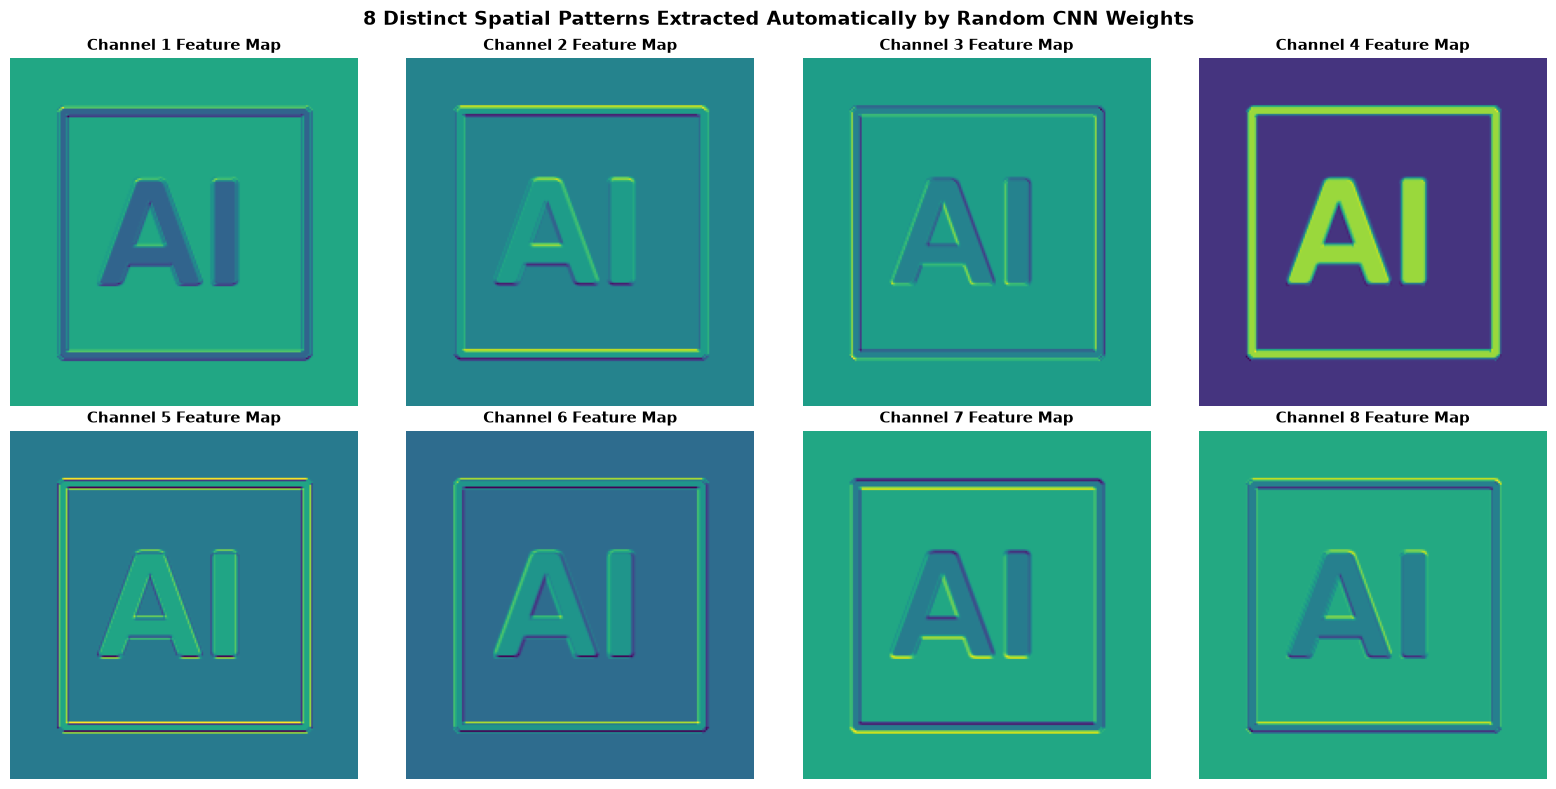

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import cv2

#plt.close('all')

# 1. Prepare image and convert to a standard PyTorch Mini-batch Tensor [B, C, H, W]
raw_img = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(raw_img, (30, 30), (170, 170), 255, 3)
cv2.putText(raw_img, "AI", (50, 130), cv2.FONT_HERSHEY_SIMPLEX, 3, 255, 5)

transform = transforms.Compose([
    transforms.ToTensor(), # Automatically scales intensities to interval [0.0, 1.0]
])
# Add batch dimension: [1, 1, 200, 200]
input_tensor = transform(raw_img).unsqueeze(0)

# 2. Construct a Tiny Network with a single Convolutional layer containing 8 learned channels
class TinyFeatureExtractor(nn.Module):
    def __init__(self):
        super(TinyFeatureExtractor, self).__init__()
        # 1 input channel (grayscale), 8 output channels, 3x3 window size
        self.conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        
    def forward(self, x):
        return self.conv(x)

# Initialize network and set to evaluation mode (stops gradient updates)
model = TinyFeatureExtractor()
model.eval()

# 3. Pass input forward through the computational graph
with torch.no_grad():
    feature_maps = model(input_tensor) # Shape matches tensor structure: [1, 8, 200, 200]

# Convert features back to numpy matrices for plotting
f_maps = feature_maps.squeeze(0).cpu().numpy()

# 4. Grid Visualization Layout
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx in range(8):
    # Slice the corresponding channel out of the tensor volume
    channel_view = f_maps[idx]
    
    # Render with an abstract map to showcase activations clearly
    axes[idx].imshow(channel_view, cmap='viridis')
    axes[idx].set_title(f"Channel {idx+1} Feature Map", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("8 Distinct Spatial Patterns Extracted Automatically by Random CNN Weights", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 14. Receptive Field

Each output value only looks at a small region of the input.

For example:

```text
Input

┌─────────────────┐
│                 │
│  ┌─────┐        │
│  │ 3×3 │        │
│  └─────┘        │
│                 │
└─────────────────┘
```

That $3\times3$ region is the **receptive field** of that output unit.

### Intuition

A neuron in the first convolutional layer sees:

> A small local part of the image.

As we stack more convolutional layers, deeper neurons effectively see larger portions of the original image.

This creates a hierarchy:

```text
Small local patterns
        ↓
Edges
        ↓
Textures
        ↓
Shapes
        ↓
Object parts
        ↓
Objects
```

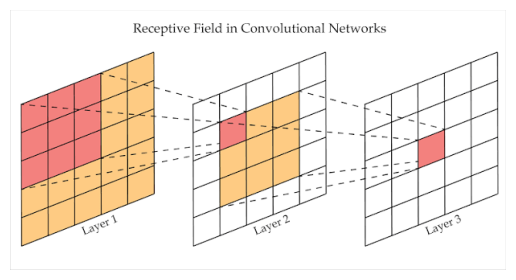

In [7]:
import cv2
import matplotlib.pyplot as plt

#plt.close('all')
img = cv2.imread("res/rp.png")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

---

# 15. Stride


So far, we moved the filter one pixel at a time.

That means:

$$
Stride = 1
$$

But we can move it by two pixels:

$$
Stride = 2
$$

Example:

```text
Stride = 1

████
  ████
    ████
```

versus:

```text
Stride = 2

████
    ████
        ████
```

Increasing stride generally reduces the spatial size of the output.

---

In [8]:

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from PIL import Image

gif_files = [
    "res/no_padding_no_strides.gif",
    "res/same_padding_no_strides.gif",
    "res/no_padding_strides.gif",
    "res/padding_strides.gif",
]

labels = [
    "padding = 0, stride = 1",
    "padding = 1, stride = 1",
    "padding = 0, stride = 2",
    "padding = 1, stride = 2",
    
]
# Load GIFs
gifs = [Image.open(f) for f in gif_files]

# Number of frames (use the longest GIF)
n_frames = max(g.n_frames for g in gifs)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

images = []
for ax, gif, label in zip(axes.ravel(), gifs, labels):
    ax.set_title(label, fontsize=12)  # add label
    ax.axis("off")
    gif.seek(0)
    img = ax.imshow(gif.convert("RGB"))
    images.append(img)

def update(frame):
    for img, gif in zip(images, gifs):
        gif.seek(frame % gif.n_frames)
        img.set_data(gif.convert("RGB"))
    return images

ani = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=100,   # milliseconds between frames
    blit=True
)

plt.close(fig)  # prevents duplicate static plot output

HTML(ani.to_jshtml())

# 16. Padding

What happens at the boundaries of the image?

A $3\times3$ filter cannot be centered on the very first pixel without going outside the image.

One solution is:

> Add padding around the image.

For example, zero padding:

```text
Original

1 2 3
4 5 6
7 8 9
```

with padding = 1:

```text
0 0 0 0 0
0 1 2 3 0
0 4 5 6 0
0 7 8 9 0
0 0 0 0 0
```

---

# 17. Why Do We Use Padding?

Padding has two important effects.

### 1. It allows the filter to process boundary pixels.

Without padding, edge pixels participate in fewer computations.

### 2. It can preserve spatial dimensions.

For example:

```text
Input:
32 × 32

Kernel:
3 × 3

Stride:
1

Padding:
1
```

Output:

```text
32 × 32
```

This is extremely common in CNNs.

---

# 18. Output Size Formula


For one spatial dimension:

$$
Output =
\left\lfloor
\frac{N+2P-K}{S}
\right\rfloor+1
$$

where:

* $N$ = input size
* $P$ = padding
* $K$ = kernel size
* $S$ = stride

> **The same formula applies independently to height and width.**

---

# 19. Example 1 — Same Spatial Size

Suppose:

$$
N=32
$$

$$
K=3
$$

$$
P=1
$$

$$
S=1
$$

Then:

$$
Output=
\left\lfloor
\frac{32+2(1)-3}{1}
\right\rfloor+1
$$

$$
29+1
$$

$$
=32
$$

Therefore:

$$
32\times32
\rightarrow
32\times32
$$

---

# 20. Example 2 — Stride = 2

Now:

$$
N=32
$$

$$
K=3
$$

$$
P=1
$$

$$
S=2
$$

Then:

$$
Output=
\left\lfloor
\frac{32+2-3}{2}
\right\rfloor+1
$$

$$
\left\lfloor
\frac{31}{2}
\right\rfloor+1
$$

$$
=15+1
$$

$$
=16
$$

Therefore:

$$
32\times32
\rightarrow
16\times16
$$

---

# 21. Class Activity — Predict the Output


Give students the following problems.

### Problem 1

```text
Input = 28
Kernel = 3
Padding = 0
Stride = 1
```

Ask:

> What is the output size?

Answer:

$$
26
$$

---

### Problem 2

```text
Input = 28
Kernel = 5
Padding = 2
Stride = 1
```

Answer:

$$
28
$$

---

### Problem 3

```text
Input = 32
Kernel = 3
Padding = 1
Stride = 2
```

Answer:

$$
16
$$

---

# 22. Why Multiple Filters?


One filter can detect one type of pattern.

For example:

```text
Filter 1 → Vertical edges
Filter 2 → Horizontal edges
Filter 3 → Diagonal patterns
Filter 4 → Texture
Filter 5 → Corners
...
```

Suppose we use 16 filters.

Then:

```text
Input
  ↓
16 Filters
  ↓
16 Feature Maps
```

Therefore:

```text
Input:
3 × 32 × 32

Conv2d:
in_channels = 3
out_channels = 16

Output:
16 × 32 × 32
```

The number of filters determines the number of output feature maps.

---

# 23. The Key Insight — CNN Learns the Filters

This is perhaps the most important conceptual point of today's session.

At first, the filters contain random values.

During training:

```text
Random Filters
      ↓
Forward Pass
      ↓
Loss
      ↓
Backpropagation
      ↓
Gradient Descent
      ↓
Updated Filters
      ↓
Better Feature Detection
```

So the network learns:

> Which visual patterns are useful for solving the task?

We don't manually tell it:

> "This filter should detect edges."

The training process discovers useful filters automatically.

---

# 24. The Hierarchical Representation

As we move deeper into the network:

### Early layers

Often learn simple local patterns:

```text
Edges
Corners
Simple textures
```

### Middle layers

Combine simple patterns:

```text
Shapes
Textures
Contours
```

### Deep layers

Represent more complex structures:

```text
Eyes
Wheels
Faces
Object parts
```

Eventually:

```text
Low-level features
       ↓
Mid-level features
       ↓
High-level features
       ↓
Object representation
       ↓
Classification
```

---

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================================
# 1. Load CIFAR-10
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


# ============================================================
# 2. Define a CNN with multiple convolutional stages
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # -------------------------
            # Early layer
            # -------------------------
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # -------------------------
            # Middle layer
            # -------------------------
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # -------------------------
            # Deeper / top layer
            # -------------------------
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNN().to(device)


# ============================================================
# 3. Train the CNN
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 5

model.train()

for epoch in range(epochs):

    total_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"Loss: {total_loss / len(loader):.4f}"
    )

100%|██████████| 170M/170M [25:03<00:00, 113kB/s]  


Epoch 1/5 Loss: 1.3728
Epoch 2/5 Loss: 0.9562
Epoch 3/5 Loss: 0.7929
Epoch 4/5 Loss: 0.6903
Epoch 5/5 Loss: 0.6078


# 25. Final Mental Model

At the end of today's session, students should have this picture in mind:

```text
                 IMAGE
                   │
                   ▼
        ┌─────────────────────┐
        │   Local Patterns     │
        │   detected by        │
        │   learnable filters  │
        └─────────────────────┘
                   │
                   ▼
             Feature Maps
                   │
                   ▼
        ┌─────────────────────┐
        │ Combine simple      │
        │ patterns into       │
        │ more complex ones   │
        └─────────────────────┘
                   │
                   ▼
             Deep Features
                   │
                   ▼
              Classifier
                   │
                   ▼
             Prediction
```

---

# 26. Key Concepts to Remember

| Concept                | Intuition                                            |
| ---------------------- | ---------------------------------------------------- |
| **Kernel / Filter**    | Small set of learnable weights that detects patterns |
| **Feature Map**        | Result produced by applying a filter                 |
| **Local Connectivity** | Each neuron looks at a small local region            |
| **Parameter Sharing**  | The same filter is reused across the image           |
| **Stride**             | How far the filter moves at each step                |
| **Padding**            | Extra pixels added around the boundary               |
| **Receptive Field**    | Region of the input influencing an output            |
| **Channels**           | Different information planes such as RGB             |
| **Multiple Filters**   | Detect different types of patterns                   |

---

# 27. Exit Questions

Use these as the final 5-minute discussion.

### Question 1

Why is a fully connected network inefficient for a $224\times224\times3$ image?

**Expected answer:**

Because it creates a very large number of parameters and does not explicitly exploit the spatial structure of images.

---

### Question 2

What is parameter sharing?

**Expected answer:**

The same filter weights are reused at different spatial locations.

---

### Question 3

What does a feature map represent?

**Expected answer:**

The response of a filter at different spatial locations in the input.

---

### Question 4

What happens when we increase stride?

**Expected answer:**

The filter moves farther at each step, generally reducing the spatial dimensions of the output.

---

### Question 5

Why do we use padding?

**Expected answer:**

To handle boundary pixels and, when appropriately chosen, preserve spatial dimensions.

---

### Question 6

Who chooses the CNN filters?

**Expected answer:**

The training process learns them through backpropagation and gradient-based optimization.

---

# 28. Homework

## Exercise 1 — Manual Convolution

Given:

$$
X=
\begin{bmatrix}
1&2&3&4&5\
2&3&4&5&6\
3&4&5&6&7\
4&5&6&7&8\
5&6&7&8&9
\end{bmatrix}
$$

and:

$$
K=
\begin{bmatrix}
1&0&-1\
1&0&-1\
1&0&-1
\end{bmatrix}
$$

calculate the complete feature map using:

```text
Stride = 1
Padding = 0
```

---

## Exercise 2 — Output Dimensions

Calculate the output dimensions for:

### A

```text
Input = 64 × 64
Kernel = 3 × 3
Stride = 1
Padding = 1
```

### B

```text
Input = 64 × 64
Kernel = 3 × 3
Stride = 2
Padding = 1
```

### C

```text
Input = 32 × 32
Kernel = 5 × 5
Stride = 1
Padding = 2
```

---

## Exercise 3 — Conceptual

Explain in your own words:

> Why does parameter sharing make CNNs more suitable for images than fully connected networks?

---

# 29. Preview of Session 2

Next session we will turn these mathematical ideas into an actual PyTorch model:

```text
Image
  ↓
Conv2d
  ↓
ReLU
  ↓
MaxPool
  ↓
Conv2d
  ↓
ReLU
  ↓
MaxPool
  ↓
Flatten
  ↓
Linear
  ↓
Class Prediction
```

We will use **CIFAR-10** and build our first complete CNN.

The central question for Session 2 will be:

> **How do the mathematical operations we learned today become actual neural-network layers in PyTorch?**